# Thí nghiệm 3: Đánh giá Stability (Sửa lỗi)


In [14]:
import os, sys, requests
if 'google.colab' in sys.modules:
    data_dir = '/content/data'
else:
    data_dir = os.path.abspath('../data') if os.path.exists('../data') else os.path.abspath('data')
os.makedirs(data_dir, exist_ok=True)
path = os.path.join(data_dir, 'bank.csv')
if not os.path.exists(path):
    r = requests.get('https://raw.githubusercontent.com/sharmaroshan/Clustering-Bank-Marketing-Dataset/master/bank.csv')
    with open(path, 'wb') as f: f.write(r.content)
print(f'✅ Dữ liệu sẵn sàng tại: {path}')


✅ Dữ liệu sẵn sàng tại: /content/data/bank.csv


In [15]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

def compare_stability(model, X, y, n_trials=50):
    single_scores = []
    for i in range(n_trials):
        # Sửa lại thứ tự split chuẩn: X_train, X_test, y_train, y_test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        
        # Fit trên Train, Score trên Test
        model.fit(X_train, y_train)
        single_scores.append(model.score(X_test, y_test))
        
    # K-Fold CV chuẩn
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kf)
    
    return single_scores, cv_scores


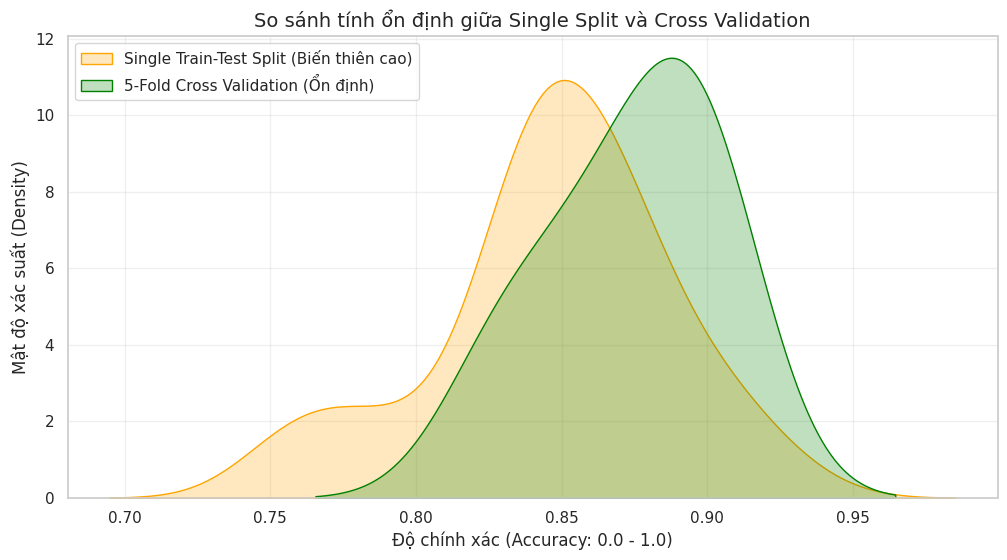

Độ lệch chuẩn Single Split: 0.0398
Độ lệch chuẩn K-Fold CV: 0.0265


In [16]:
# Tạo dữ liệu mẫu cho bài toán phân lớp (Classification)
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)
model = DecisionTreeClassifier(max_depth=5)

s, c = compare_stability(model, X, y)

plt.figure(figsize=(12, 6))
sns.kdeplot(s, label='Single Train-Test Split (Biến thiên cao)', fill=True, color='orange')
sns.kdeplot(c, label='5-Fold Cross Validation (Ổn định)', fill=True, color='green')

plt.title('So sánh tính ổn định giữa Single Split và Cross Validation', fontsize=14)
plt.xlabel('Độ chính xác (Accuracy: 0.0 - 1.0)')
plt.ylabel('Mật độ xác suất (Density)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Độ lệch chuẩn Single Split: {np.std(s):.4f}")
print(f"Độ lệch chuẩn K-Fold CV: {np.std(c):.4f}")
